Example: 3D Frame 2 storey


In [1]:
!pip install openseespy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 MB 7.8 MB/s eta 0:00:00


In [2]:
!pip install opsvis matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 2.5 MB/s eta 0:00:00


In [ ]:
!pip install plotly

Learning Opensees
FIRST MODEL

This OpenSeesPy script creates a 3D two-storey reinforced concrete frame model with a 2-bay × 2-bay configuration in both the X and Y directions. The building geometry is defined using a bay spacing of 4 m and a storey height of 3 m, resulting in an overall plan dimension of 8 m × 8 m and a total height of 6 m. The model is created as a three-dimensional structural system with 6 degrees of freedom per node, allowing translation and rotation in all directions. The beam and column members are modeled using a 230 mm × 230 mm elastic section, where the cross-sectional properties such as area, moment of inertia, and torsional constant are calculated from the section dimensions. A linear geometric transformation and a Lobatto beam integration rule with five integration points are assigned to the beam-column elements.

The structural model consists of nodes generated at all column intersections and floor levels, with the base nodes fully fixed to represent fixed supports. Vertical columns are created between consecutive storeys, while beams are modeled in both the X and Y directions to form the complete 3D frame. A slab thickness of 125 mm is considered, and the self-weight of the concrete slab is converted into equivalent nodal loads using tributary area calculations. These gravity loads are applied at the floor nodes through a static load pattern. The model is then visualized using opsvis and Matplotlib 3D plotting, allowing the user to view the complete building frame with node and element labels. The final output provides information about the total number of nodes and elements, confirming successful generation of the structural model.

Overall, this script represents the initial elastic structural model stage of an RC building, which can later be upgraded by replacing the elastic sections with nonlinear fiber sections for seismic and advanced nonlinear analysis.

-------------------------------------
Floor Seismic Weight = 383.73375 kN
Floor Mass = 39116.59021406728 kg
-------------------------------------
Gravity Analysis Successful
-------------------------------------
Base Reactions
-------------------------------------
Rx = -1.4210854715202004e-17 kN
Ry = 9.947598300641403e-17 kN
Rz = 1649.3212500000002 kN
Mx = -2.415845301584341e-16 kN-m
My = -7.105427357601002e-18 kN-m
Mz = -5.5830103085517935e-18 kN-m
Node: 1 Rx = 0.042675515641302765 kN Ry = 0.04267551564130278 kN Rz = 127.07329133658777 kN
Node: 2 Rx = -3.730210249332904e-17 kN Ry = 0.06208056819831297 kN Rz = 205.23451374127484 kN
Node: 3 Rx = -0.04267551564130274 kN Ry = 0.04267551564130276 kN Rz = 127.07329133658777 kN
Node: 4 Rx = 0.06208056819831297 kN Ry = -2.4983609651709056e-17 kN Rz = 205.23451374127478 kN
Node: 5 Rx = -6.546474651708512e-17 kN Ry = -5.2733050261124184e-17 kN Rz = 320.0900296885497 kN
Node: 6 Rx = -0.06208056819831294 kN Ry = -1.2676238290608189e-17 kN Rz = 20

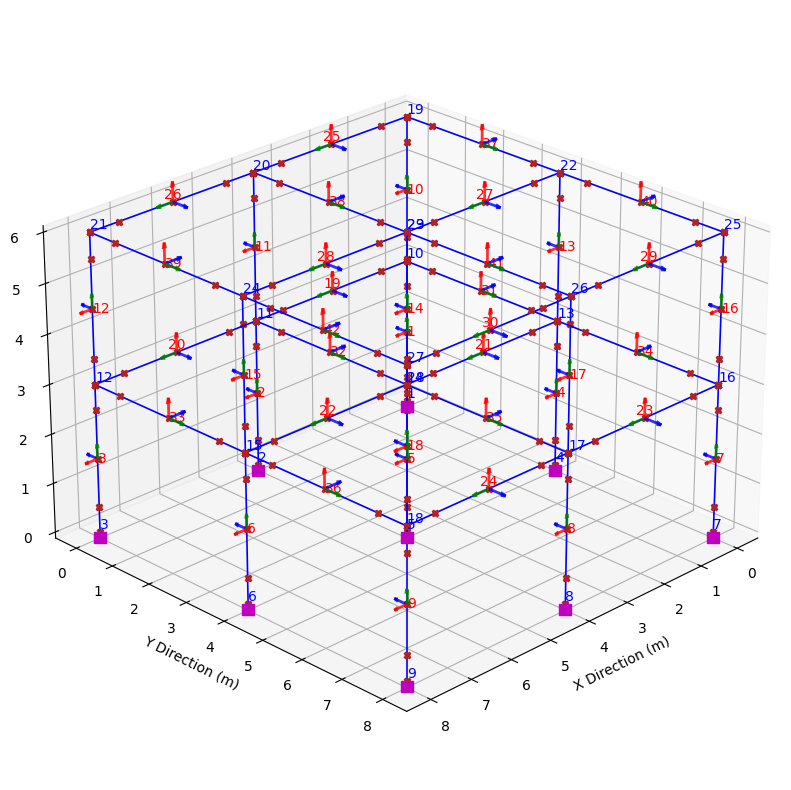

-------------------------------------
Model Successfully Generated
-------------------------------------
Nodes : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Number of Nodes : 29
Number of Elements : 42


In [17]:
import openseespy.opensees as ops
import math
import matplotlib.pyplot as plt
import opsvis as opsv
import plotly.graph_objects as go

ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)

# ------------------------------------------------------------
# Geometry
# ------------------------------------------------------------
bayX = 4.0
bayY = 4.0
nBayX = 2
nBayY = 2

storyHeight = 3.0
nStory = 2

# ------------------------------------------------------------
# Material Properties
# ------------------------------------------------------------
Ec = 25e9          # Pa (Concrete modulus)
rho = 2500         # kg/m3

# Beam and Column Size
b = 0.23
h = 0.23

A = b*h
Iz = b*h**3/12
Iy = h*b**3/12
J = Iy + Iz

# ------------------------------------------------------------
# Nodes
# ------------------------------------------------------------
nodeTag = 1
nodeMap = {}

for k in range(nStory+1):
    z = k*storyHeight
    for j in range(nBayY+1):
        y = j*bayY
        for i in range(nBayX+1):
            x = i*bayX

            ops.node(nodeTag, x, y, z)
            nodeMap[(i,j,k)] = nodeTag

            if k == 0:
                ops.fix(nodeTag,1,1,1,1,1,1)

            nodeTag += 1

# ------------------------------------------------------------
# Master diaphragm nodes
# ------------------------------------------------------------
masterNodes = {}

masterTag = nodeTag      # Continue numbering after existing nodes

for k in range(1, nStory + 1):

    z = k * storyHeight

    ops.node(masterTag, bayX * nBayX / 2, bayY * nBayY / 2, z)
     # Restrain unnecessary DOFs of the master node
    ops.fix(masterTag, 0, 0, 1, 1, 1, 0)

    masterNodes[k] = masterTag

    masterTag += 1

# ------------------------------------------------------------
# Rigid Diaphragm Constraints
# ------------------------------------------------------------
for k in range(1, nStory + 1):

    master = masterNodes[k]

    slaveNodes = []

    for j in range(nBayY + 1):
        for i in range(nBayX + 1):
            slaveNodes.append(nodeMap[(i, j, k)])

    ops.rigidDiaphragm(3, master, *slaveNodes)

# ------------------------------------------------------------
# Geometric Transformation
# ------------------------------------------------------------
ops.geomTransf('Linear', 1, 1, 0, 0)   # columns
ops.geomTransf('Linear', 2, 0, 0, 1)   # all beams (X and Y)

# ------------------------------------------------------------
# Elastic Section
# ------------------------------------------------------------
ops.section('Elastic',1,Ec,A,Iz,Iy,Ec/2.4,J)

# ------------------------------------------------------------
# Beam Integration
# ------------------------------------------------------------
ops.beamIntegration('Lobatto',1,1,5)

eleTag = 1

# Lists to store element IDs
beamTags = []
columnTags = []


# ------------------------------------------------------------
# Columns
# ------------------------------------------------------------
# ------------------------------------------------------------
# Columns
# ------------------------------------------------------------
for k in range(nStory):
    for j in range(nBayY+1):
        for i in range(nBayX+1):

            n1 = nodeMap[(i,j,k)]
            n2 = nodeMap[(i,j,k+1)]

            ops.element(
                'dispBeamColumn',
                eleTag,
                n1,
                n2,
                1,
                1
            )

            columnTags.append(eleTag)

            eleTag += 1
# ------------------------------------------------------------
# Beams X-direction
# ------------------------------------------------------------
for k in range(1,nStory+1):
    for j in range(nBayY+1):
        for i in range(nBayX):

            n1 = nodeMap[(i,j,k)]
            n2 = nodeMap[(i+1,j,k)]

            ops.element(
                'dispBeamColumn',
                eleTag,
                n1,
                n2,
                2,
                1
            )

            beamTags.append(eleTag)
            eleTag += 1


# ------------------------------------------------------------
# Beams Y-direction
# ------------------------------------------------------------
for k in range(1, nStory+1):
    for j in range(nBayY):
        for i in range(nBayX+1):

            n1 = nodeMap[(i,j,k)]
            n2 = nodeMap[(i,j+1,k)]

            ops.element(
                'dispBeamColumn',
                eleTag,
                n1,
                n2,
                2,
                1
            )

            beamTags.append(eleTag)
            eleTag += 1

# ------------------------------------------------------------
# Floor Loads from Slab
# ------------------------------------------------------------
slabThickness = 0.125
gammaConcrete = 25e3      # N/m3

liveLoad = 0.6e3            # N/m2 30% of 2kn/m2=0.6
floorfinishLoad = 1e3     # N/m2

slabLoad = slabThickness * gammaConcrete   # N/m2

totalAreaLoad = slabLoad + floorfinishLoad + liveLoad

tributaryAreaInterior = bayX*bayY

ops.timeSeries('Linear',1)
ops.pattern('Plain',1,1)

for k in range(1,nStory+1):
    for j in range(nBayY+1):
        for i in range(nBayX+1):

            area = tributaryAreaInterior

            if i==0 or i==nBayX:
                area *= 0.5

            if j==0 or j==nBayY:
                area *= 0.5

            P = totalAreaLoad * area
            ops.load(nodeMap[(i,j,k)], 0, 0, -P, 0, 0, 0)




# Floor Load Beam

beamArea = b * h

beamLoad = gammaConcrete * beamArea      # N/m
#Apply to X-Beams
for k in range(1, nStory+1):
    for j in range(nBayY+1):
        for i in range(nBayX):

            n1 = nodeMap[(i,j,k)]
            n2 = nodeMap[(i+1,j,k)]

            L = bayX

            P = beamLoad * L / 2

            ops.load(n1,0,0,-P,0,0,0)
            ops.load(n2,0,0,-P,0,0,0)

 # Apply to Y- Beams
for k in range(1,nStory+1):
    for j in range(nBayY):
        for i in range(nBayX+1):

            n1 = nodeMap[(i,j,k)]
            n2 = nodeMap[(i,j+1,k)]

            L = bayY

            P = beamLoad * L / 2

            ops.load(n1,0,0,-P,0,0,0)
            ops.load(n2,0,0,-P,0,0,0)

#Column Self Weight
columnArea = b*h
columnLoad = gammaConcrete * columnArea
storyHeight = 3.0
Wcolumn = columnLoad * storyHeight
P = Wcolumn/2
for k in range(nStory):
    for j in range(nBayY+1):
        for i in range(nBayX+1):

            n1 = nodeMap[(i,j,k)]
            n2 = nodeMap[(i,j,k+1)]

            P = columnLoad * storyHeight / 2

            # Don't apply load to fixed base nodes
            if k > 0:
                ops.load(n1,0,0,-P,0,0,0)

            ops.load(n2,0,0,-P,0,0,0)

#wall load 9kn/m in each beam
wallLoad = 9e3      # N/m
#Wall load X-direction beams
for k in range(1, nStory+1):
    for j in range(nBayY+1):
        for i in range(nBayX):

            n1 = nodeMap[(i,j,k)]
            n2 = nodeMap[(i+1,j,k)]

            P = wallLoad * bayX / 2

            ops.load(n1,0,0,-P,0,0,0)
            ops.load(n2,0,0,-P,0,0,0)

#Wall Load Y-direction beams
for k in range(1,nStory+1):
    for j in range(nBayY):
        for i in range(nBayX+1):

            n1 = nodeMap[(i,j,k)]
            n2 = nodeMap[(i,j+1,k)]

            P = wallLoad * bayY / 2

            ops.load(n1,0,0,-P,0,0,0)
            ops.load(n2,0,0,-P,0,0,0)

# ------------------------------------------------------------
# Mass Assignment
# ------------------------------------------------------------

g = 9.81     # m/s2

# -----------------------------------
# Floor mass from slab + finish + 30% live load
# -----------------------------------

floorArea = (bayX*nBayX) * (bayY*nBayY)

# Area load (already calculated)
floorWeight = totalAreaLoad * floorArea


# -----------------------------------
# Beam self weight per floor
# -----------------------------------

beamWeightPerFloor = 0

for k in range(1, nStory+1):

    beamWeight = 0

    # X beams
    for j in range(nBayY+1):
        for i in range(nBayX):

            beamWeight += beamLoad * bayX


    # Y beams
    for j in range(nBayY):
        for i in range(nBayX+1):

            beamWeight += beamLoad * bayY


    beamWeightPerFloor += beamWeight



# Average beam weight per floor
beamWeightPerFloor = beamWeightPerFloor / nStory



# -----------------------------------
# Column weight contribution
# -----------------------------------

columnWeightPerFloor = 0

numberOfColumns = (nBayX+1)*(nBayY+1)

columnWeightPerFloor = (
    numberOfColumns *
    columnLoad *
    storyHeight
)


# For seismic mass:
# Half column weight from above + half from below
columnWeightPerFloor *= 0.5



# -----------------------------------
# Total seismic weight per floor
# -----------------------------------

floorSeismicWeight = (
    floorWeight +
    beamWeightPerFloor +
    columnWeightPerFloor
)


# Convert weight to mass
floorMass = floorSeismicWeight/g
Lx = bayX*nBayX
Ly = bayY*nBayY

Izz = floorMass*(Lx**2 + Ly**2)/12


print("-------------------------------------")
print("Floor Seismic Weight =", floorSeismicWeight/1000, "kN")
print("Floor Mass =", floorMass, "kg")
print("-------------------------------------")



# -----------------------------------
# Assign mass to diaphragm master nodes
# -----------------------------------

for k in range(1, nStory+1):

    master = masterNodes[k]

    ops.mass(
    master,
    floorMass,
    floorMass,
    0,
    0,
    0,
    Izz
)

# ------------------------------------------------------------
# Gravity Analysis
# ------------------------------------------------------------

ops.system('BandGeneral')

ops.numberer('RCM')

ops.constraints('Transformation')

ops.test(
    'NormDispIncr',
    1.0e-6,
    100
)

ops.algorithm('Newton')

ops.integrator(
    'LoadControl',
    1.0
)

ops.analysis('Static')


gravityResult = ops.analyze(1)


if gravityResult == 0:
    print("Gravity Analysis Successful")
else:
    print("Gravity Analysis Failed")

ops.loadConst('-time',0.0)


# ------------------------------------------------------------
# Base Reactions Totalll
# ------------------------------------------------------------

ops.reactions()

totalRx = 0
totalRy = 0
totalRz = 0
totalMx = 0
totalMy = 0
totalMz = 0


for k in range(nBayY+1):
    for j in range(nBayX+1):

        node = nodeMap[(j,k,0)]   # base nodes only

        reaction = ops.nodeReaction(node)

        totalRx += reaction[0]
        totalRy += reaction[1]
        totalRz += reaction[2]

        totalMx += reaction[3]
        totalMy += reaction[4]
        totalMz += reaction[5]


print("-------------------------------------")
print("Base Reactions")
print("-------------------------------------")
print("Rx =", totalRx/1000, "kN")
print("Ry =", totalRy/1000, "kN")
print("Rz =", totalRz/1000, "kN")
print("Mx =", totalMx/1000, "kN-m")
print("My =", totalMy/1000, "kN-m")
print("Mz =", totalMz/1000, "kN-m")

#---------------------Base Reaction For each node at base---------
#-----------------------------------------------------------------------------

ops.reactions()

for j in range(nBayY+1):
    for i in range(nBayX+1):

        node = nodeMap[(i,j,0)]

        R = ops.nodeReaction(node)

        print(
            "Node:",
            node,
            "Rx =",
            R[0]/1000,
            "kN",
            "Ry =",
            R[1]/1000,
            "kN",
            "Rz =",
            R[2]/1000,
            "kN"
        )

# ------------------------------------------------------------
# Eigenvalue Analysis
# ------------------------------------------------------------

numModes = 3

eigenValues = ops.eigen(numModes)


for i in range(numModes):

    omega = math.sqrt(eigenValues[i])

    period = 2*math.pi/omega

    print(
        "Mode",
        i+1,
        "Period =",
        period,
        "sec"
    )

for mode in range(1,4):

    print("\nMode",mode)

    for node in masterNodes.values():

        vec = ops.nodeEigenvector(node,mode)

        print(
            "Node",
            node,
            "Ux=",
            vec[0],
            "Uy=",
            vec[1],
            "Rz=",
            vec[5]
        )

#------------------------------------ Plotting----------
#-----------------------------------------------------------------------

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import opsvis as opsv

fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(111, projection='3d')

opsv.plot_model(
    ax=ax,
    node_labels=1,
    element_labels=1
)

ax.set_xlabel("X Direction (m)")
ax.set_ylabel("Y Direction (m)")
ax.set_zlabel("Height (m)")



# Initial viewing angle
ax.view_init(
    elev=25,   # vertical angle
    azim=45    # horizontal rotation
)

plt.show()



print("-------------------------------------")
print("Model Successfully Generated")
print("-------------------------------------")
print("Nodes :", ops.getNodeTags())
print("Number of Nodes :", len(ops.getNodeTags()))
print("Number of Elements :", eleTag-1)


Fiber-Section Modeling

This OpenSeesPy script develops a nonlinear reinforced concrete (RC) fiber section model for a 230 mm × 230 mm beam/column section reinforced with four 16 mm diameter steel bars. The model is created using N-mm-MPa units and begins by defining the section geometry, including the overall dimensions and concrete cover thickness. The concrete core dimensions are calculated by subtracting the cover from both sides of the section. Nonlinear material models are assigned using Concrete02 for concrete and Steel02 for reinforcement, allowing the section to simulate realistic behavior such as concrete cracking, crushing, steel yielding, and post-yield deformation. The fiber section is then created with an assigned torsional stiffness (GJ), and the concrete area is divided into multiple fibers using rectangular patches to represent confined core concrete and unconfined cover concrete. Four steel fibers are added at the corner locations of the section to represent the 4Ø16 reinforcement bars. Finally, a Matplotlib-based visualization is included to display the section geometry, where the concrete cover, concrete core, and reinforcement locations can be clearly identified. This fiber section model provides a nonlinear representation of an RC member and can later be integrated into nonlinear beam-column elements for advanced analysis such as pushover or earthquake response analysis

--------------------------------
Nonlinear Fiber Section Created
--------------------------------
Section size : 230 x 230 mm
Reinforcement: 4 bars Ø16 mm
Concrete mat : Concrete02
Steel mat    : Steel02
--------------------------------


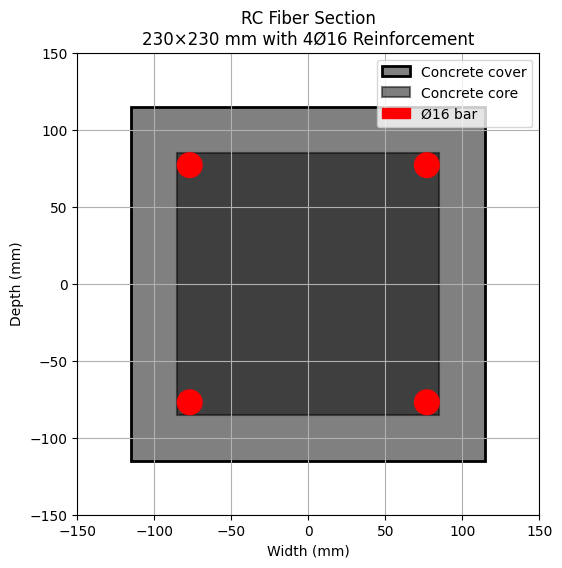

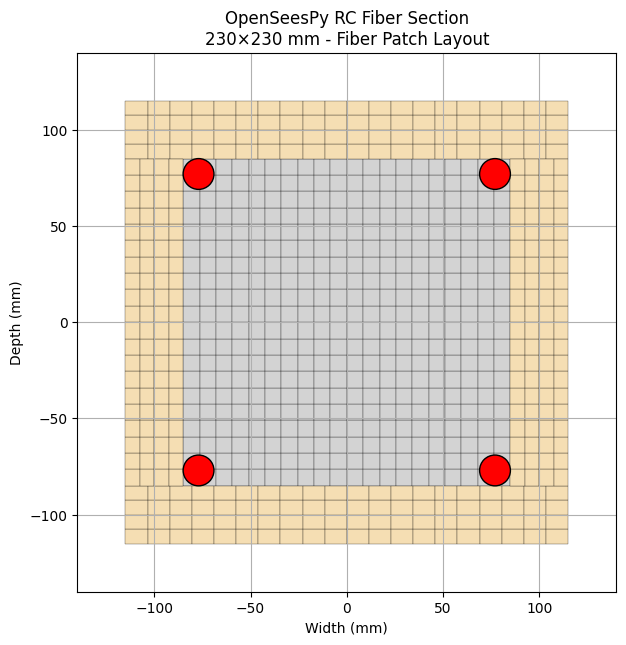

In [8]:
# ============================================================
# Nonlinear RC Fiber Section Model
# 230 mm x 230 mm section
# 4 bars of 16 mm diameter
# OpenSeesPy
# ============================================================

import openseespy.opensees as ops
import matplotlib.pyplot as plt
import math

ops.wipe()

# ------------------------------------------------------------
# Units: N, mm
# ------------------------------------------------------------

# Section dimensions
B = 230       # mm
H = 230       # mm

# Concrete cover
cover = 30    # mm

# Reinforcement
barDia = 16
barArea = math.pi*(barDia**2)/4

# ------------------------------------------------------------
# Material Properties
Ec = 25000   # MPa
# ------------------------------------------------------------

# Concrete Cover Unconfined
#fc = -25      # MPa
#epsc0 = -0.002

#fcu = -20     # MPa
#epscu = -0.0035

#lambdaC = 0.1
#ft = 2.5
#Ets = 200

ops.uniaxialMaterial(
    'Concrete02',
    1,
    -25,
    -0.002,
    -20,
    -0.0035,
    0.1,
    2.5,
    200
)



# Concrete Core Confined
#fc = -30      # MPa
#epsc0 = -0.003

#fcu = -25    # MPa
#epscu = -0.008

#lambdaC = 0.1
#ft = 2.5
#Ets = 200
# Concrete material


ops.uniaxialMaterial(
    'Concrete02',
    3,
    -30,
    -0.003,
    -25,
    -0.008,
    0.1,
    2.5,
    200
)


# Steel
fy = 500      # MPa
Es = 200000   # MPa
b = 0.01

ops.uniaxialMaterial(
    'Steel02',
    2,
    fy,
    Es,
    b
)


# ------------------------------------------------------------
# Fiber Section
# ------------------------------------------------------------

sectionTag = 1

# Torsional stiffness
G = Ec/(2*(1+0.2))     # Shear modulus (assuming Poisson ratio = 0.2)

J = 0.141*B**4           # approximate torsional constant for square section

GJ = G*J

ops.section(
    'Fiber',
    sectionTag,
    '-GJ',
    GJ
)

# ------------------------------------------------------------
# Concrete Core
# ------------------------------------------------------------

coreB = B - 2*cover
coreH = H - 2*cover


ops.patch(
    'rect',
    3,
    20,
    20,
    -coreB/2,
    -coreH/2,
     coreB/2,
     coreH/2
)


# ------------------------------------------------------------
# Concrete Cover
# ------------------------------------------------------------

# Bottom cover
ops.patch(
    'rect',
    1,
    20,
    4,
    -B/2,
    -H/2,
    B/2,
    -coreH/2
)

# Top cover
ops.patch(
    'rect',
    1,
    20,
    4,
    -B/2,
    coreH/2,
    B/2,
    H/2
)

# Left cover
ops.patch(
    'rect',
    1,
    4,
    20,
    -B/2,
    -coreH/2,
    -coreB/2,
    coreH/2
)

# Right cover
ops.patch(
    'rect',
    1,
    4,
    20,
    coreB/2,
    -coreH/2,
    B/2,
    coreH/2
)
# ------------------------------------------------------------
# Reinforcement Bars
# ------------------------------------------------------------

barOffset = B/2 - cover - barDia/2

barCoords=[
(-barOffset,-barOffset),
(barOffset,-barOffset),
(-barOffset,barOffset),
(barOffset,barOffset)
]


for x,y in barCoords:

    ops.fiber(
        x,
        y,
        barArea,
        2
    )


print("--------------------------------")
print("Nonlinear Fiber Section Created")
print("--------------------------------")
print("Section size : 230 x 230 mm")
print("Reinforcement: 4 bars Ø16 mm")
print("Concrete mat : Concrete02")
print("Steel mat    : Steel02")
print("--------------------------------")



# ============================================================
# Fiber Section Visualization
# ============================================================

import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6,6))

# Outer concrete section
outer = patches.Rectangle(
    (-B/2, -H/2),
    B,
    H,
    linewidth=2,
    edgecolor='black',
    facecolor='grey',
    label="Concrete cover"
)

ax.add_patch(outer)


# Concrete core
core = patches.Rectangle(
    (-coreB/2, -coreH/2),
    coreB,
    coreH,
    linewidth=1.5,
    edgecolor='black',
    facecolor='black',
    alpha=0.5,
    label="Concrete core"
)

ax.add_patch(core)


# Reinforcement bars
for x, y in barCoords:

    bar = patches.Circle(
        (x,y),
        barDia/2,
        color='red',
        label="Ø16 bar"
    )

    ax.add_patch(bar)


# Formatting
ax.set_xlim(-150,150)
ax.set_ylim(-150,150)

ax.set_xlabel("Width (mm)")
ax.set_ylabel("Depth (mm)")

ax.set_title(
    "RC Fiber Section\n230×230 mm with 4Ø16 Reinforcement"
)

ax.set_aspect('equal')

ax.grid(True)

# Remove duplicate legend labels
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.legend(by_label.values(), by_label.keys())

plt.show()






# ============================================================
# Fiber Patch Visualization
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(7,7))





# ------------------------------------------------------------
# Function to draw rectangular fiber patches
# ------------------------------------------------------------

def draw_patch(x1, y1, x2, y2, nx, ny, color):

    dx = (x2-x1)/nx
    dy = (y2-y1)/ny

    for i in range(nx):
        for j in range(ny):

            rect = patches.Rectangle(
                (x1+i*dx, y1+j*dy),
                dx,
                dy,
                linewidth=0.2,
                edgecolor='black',
                facecolor=color
            )

            ax.add_patch(rect)


# ------------------------------------------------------------
# Confined Concrete Core
# ------------------------------------------------------------

draw_patch(
    -coreB/2,
    -coreH/2,
     coreB/2,
     coreH/2,
    20,
    20,
    'lightgray'
)


# ------------------------------------------------------------
# Concrete Cover Patches
# ------------------------------------------------------------

# Bottom cover
draw_patch(
    -B/2,
    -H/2,
     B/2,
    -coreH/2,
    20,
    4,
    'wheat'
)


# Top cover
draw_patch(
    -B/2,
     coreH/2,
     B/2,
     H/2,
    20,
    4,
    'wheat'
)


# Left cover
draw_patch(
    -B/2,
    -coreH/2,
    -coreB/2,
     coreH/2,
    4,
    20,
    'wheat'
)


# Right cover
draw_patch(
     coreB/2,
    -coreH/2,
     B/2,
     coreH/2,
    4,
    20,
    'wheat'
)



# ------------------------------------------------------------
# Reinforcement bars
# ------------------------------------------------------------

for x,y in barCoords:

    circle = patches.Circle(
        (x,y),
        barDia/2,
        color='red',
        ec='black'
    )

    ax.add_patch(circle)



# ------------------------------------------------------------
# Plot formatting
# ------------------------------------------------------------

ax.set_xlim(-140,140)
ax.set_ylim(-140,140)

ax.set_xlabel("Width (mm)")
ax.set_ylabel("Depth (mm)")

ax.set_title(
    "OpenSeesPy RC Fiber Section\n230×230 mm - Fiber Patch Layout"
)

ax.set_aspect('equal')

ax.grid(True)

plt.show()

The total gravity load of an RC building consists of all vertical loads acting on the structure due to its own weight and applied usage loads. It is generally expressed as the combination of dead loads and live loads, where dead loads represent permanent loads that remain throughout the life of the structure, and live loads represent variable loads due to occupancy and movable items. The total gravity load can be written as:

Total Gravity Load=D+L

where D (Dead Load) includes the self-weight of the slab, beams, columns, walls, floor finishes, ceilings, mechanical and electrical services, and other permanent equipment. L (Live Load) includes loads due to occupants, furniture, temporary storage, and other movable loads depending on the building function. These gravity loads are applied in the structural model using load patterns (such as ops.load() in OpenSees) and are used for gravity analysis to determine internal forces and reactions. For seismic analysis, the dead load and an appropriate portion of the live load are converted into mass using the relationship M=
g
D+ψL
	​

, where ψ is the code-specified live load participation factor.

The gravity load is important for static analysis and gravity load analysis because it represents the actual vertical forces acting on the structure under normal service conditions. These loads are used to determine the structural response due to self-weight and applied loads, including member forces, bending moments, shear forces, axial forces, and support reactions. In addition, applying gravity loads before seismic analysis is important because it establishes the initial stress state of the structure and accounts for the effects of constant vertical loads on the overall structural behavior. In OpenSees, gravity loads are generally applied using load patterns and ops.load() commands.

The mass of the structure is important for dynamic analysis, modal analysis, and earthquake analysis because it represents the inertia of the building when subjected to time-dependent forces. During an earthquake, the ground motion causes the building mass to resist acceleration, producing inertial forces according to Newton’s second law:

F=m×a

The assigned mass is used in eigenvalue analysis to calculate the natural periods and mode shapes of the structure, and it is also required for response spectrum and time-history analyses. In seismic analysis, the mass is usually obtained from the dead load plus a code-specified portion of the live load:

M=
g
D+ψL
	​


and is assigned to the structural nodes using ops.mass() in OpenSees. Therefore, gravity loads define the vertical demand and initial structural condition, while masses control the dynamic response and earthquake-induced forces of the building.